In [75]:
import matplotlib.pyplot as plt
import csv
from collections import defaultdict
def get_APD(voltage, dt,APD_percentage = 0.1): # lib is 2D array, each row is a time series of one pixel
    def linear_interpolation(y0,y1,x0,x1,x):
        
        return (y0 * (x1-x) + y1 * (x-x0)) / (x1-x0)
    APD_percentage = APD_percentage * (max(voltage) - min(voltage)) + min(voltage)
    APD_start_point = None
    APD_end_point = None
    start_apd = False
    APD_value = 0
    APD_start_error = -100
    APD_end_error = -100
    for j in range(len(voltage)):


        if start_apd == False and voltage[j] > APD_percentage:
            start_apd = True
            if j == 0:
                APD_start_error = 0
            else:
                APD_start_error = linear_interpolation(1,0,voltage[j],voltage[j-1],APD_percentage)
                APD_start_error = 1 - APD_start_error
            APD_start_point = j - 1 + APD_start_error
        if start_apd == True and voltage[j] <= APD_percentage: 
            start_apd = False
            APD_end_error = linear_interpolation(0,-1,voltage[j],voltage[j-1],APD_percentage)
            APD_end_point = j + APD_end_error
            APD_value += (APD_start_error + APD_end_error) * dt                
            APD_start_error = -100
            APD_end_error = -100
        if start_apd == True:
            APD_value += dt
    return APD_value,[APD_start_point,APD_end_point]
def get_dvdt_max_and_plateau_duration(voltage,dt):
    dvdt_max = -1e6
    dvdt_plateau_lower_bound = -0.350
    plateau_duration = 0
    plateau_end_idx = None
    for j in range(1,len(voltage)):
        dvdt = (voltage[j] - voltage[j-1]) / dt
        plateau_duration += dt
        if dvdt > dvdt_max:
            dvdt_max = dvdt
        if dvdt < 0 and j > 100 and dvdt < dvdt_plateau_lower_bound:
            plateau_end_idx = j
            return dvdt_max, plateau_duration, plateau_end_idx
    return dvdt_max, plateau_duration, plateau_end_idx

In [ ]:
# Create an 8x10 grid (80 slots for 75 images)
fig, axs = plt.subplots(8, 10, figsize=(20, 16))

# Flatten the grid to a single list for easy looping
for i, ax in enumerate(axs.flat):
    if i < 75:
        try:
            # Generate path for Na = 0.1 to 7.5
            path = rf"C:\Users\xan37\Downloads\C_Na_{(i+1)/10:.2f}_time_1000_0.8_0.8.png"
            img = plt.imread(path)
            
            # Show image with your specific coordinate extent
            ax.imshow(img, extent=[0, img.shape[1], 0, img.shape[0]])
            ax.set_title(f"Na={(i+1)/10:.1f}", fontsize=8)
        except: pass
    
    ax.axis('off') # Hide axis lines for cleanness

plt.tight_layout()
plt.savefig("TNNP_Na_Variation.png", dpi=300)

In [2]:
# read csv
csv_file = r".\result_Na.csv"
step = None
voltage = {}
with open(csv_file, 'r') as file:
    reader = csv.reader(file, delimiter=',')
    cur_v = []
    for row in reader:
        if len(row) == 1:
            key = round(float(row[0]), 3) # float to digit 2
            voltage[key] = cur_v
            continue
        cur_v = [float(v) for v in row if v]
# APD = get_APD(voltage, dt=step, APD_percentage=0.3)



In [106]:
#seperate action potential of a given voltage signal
# it should start when dv/dt begins > 0 and v < 0
# it should end when next start
# deleat first/last AP if incomplete
# output APs and all startiing indexes
def get_AP(voltage_signal):
    APs = []
    starting_indexes = []
    current_AP = []
    in_AP = False
    for i in range(1, len(voltage_signal)):
        dv_dt = voltage_signal[i] - voltage_signal[i-1]
        if not in_AP:
            if dv_dt > 0 and voltage_signal[i-1] < 0:
                in_AP = True
                current_AP = [voltage_signal[i-1], voltage_signal[i]]
                current_AP_start_idx = i - 1
                starting_indexes.append(current_AP_start_idx)
        else:
            current_AP.append(voltage_signal[i])
            if i + 1 < len(voltage_signal):
                next_dv_dt = voltage_signal[i+1] - voltage_signal[i]
                if next_dv_dt > 0 and voltage_signal[i] < 0 and len(current_AP) > 5000:
                    in_AP = False
                    APs.append(current_AP)
                    current_AP = []    
    return APs, starting_indexes



In [122]:
APD_90_lst = []
plateau_duration_lst = []
dv_dt_max_lst = []
v_peak_lst = []
RMP_lst = []

for key_Na in sorted(voltage.keys()):
    APs, starting_indexes = get_AP(voltage[key_Na])
    
    last_AP = APs[-1]
    
    APD_90, APD_points = get_APD(last_AP, dt=0.2, APD_percentage=0.1) # dt=0.2 ms
    dvdt_max, plateau_duration, plateau_end_idx = get_dvdt_max_and_plateau_duration(last_AP, dt=0.2) # dt=0.2 ms
    v_peak = max(last_AP)
    RMP = min(last_AP)
    
    APD_90_lst.append(APD_90)
    plateau_duration_lst.append(plateau_duration)
    dv_dt_max_lst.append(dvdt_max)
    v_peak_lst.append(v_peak)
    RMP_lst.append(RMP)


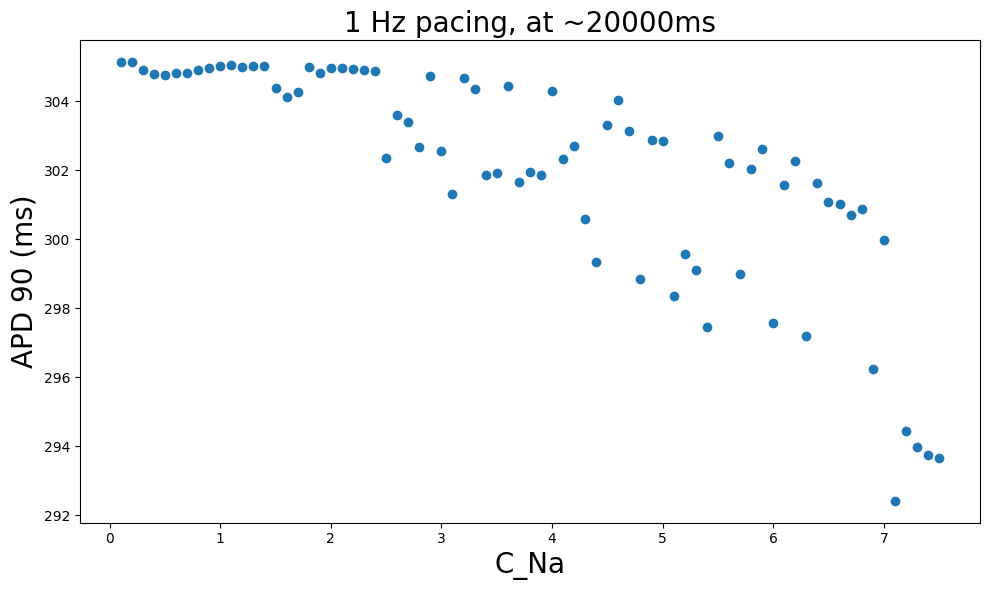

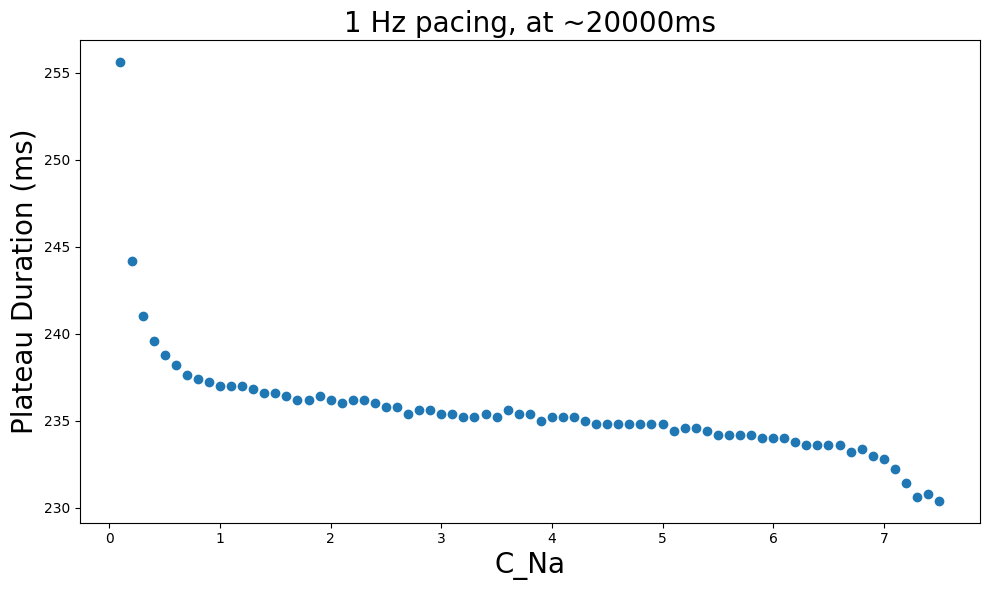

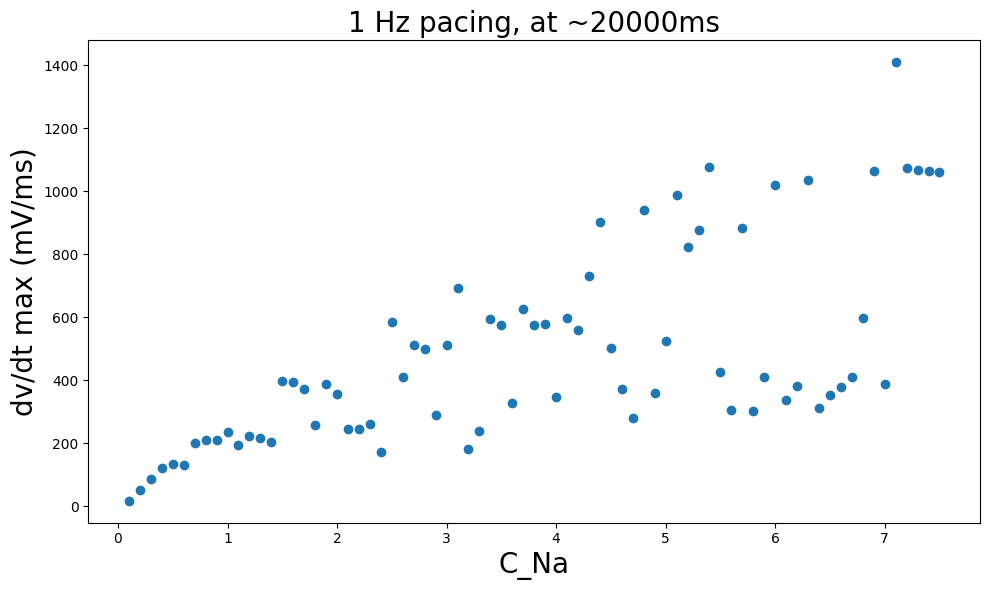

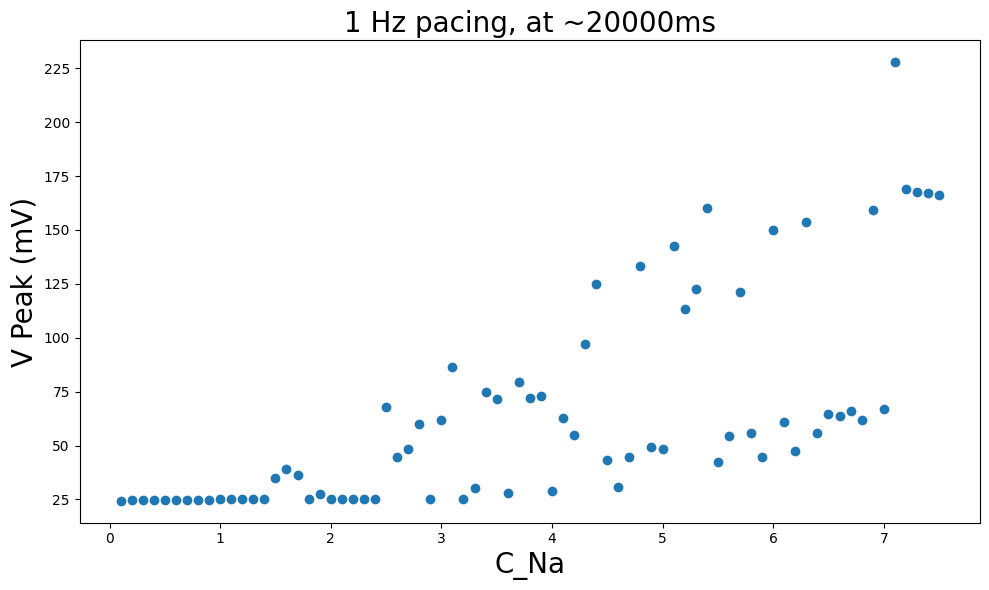

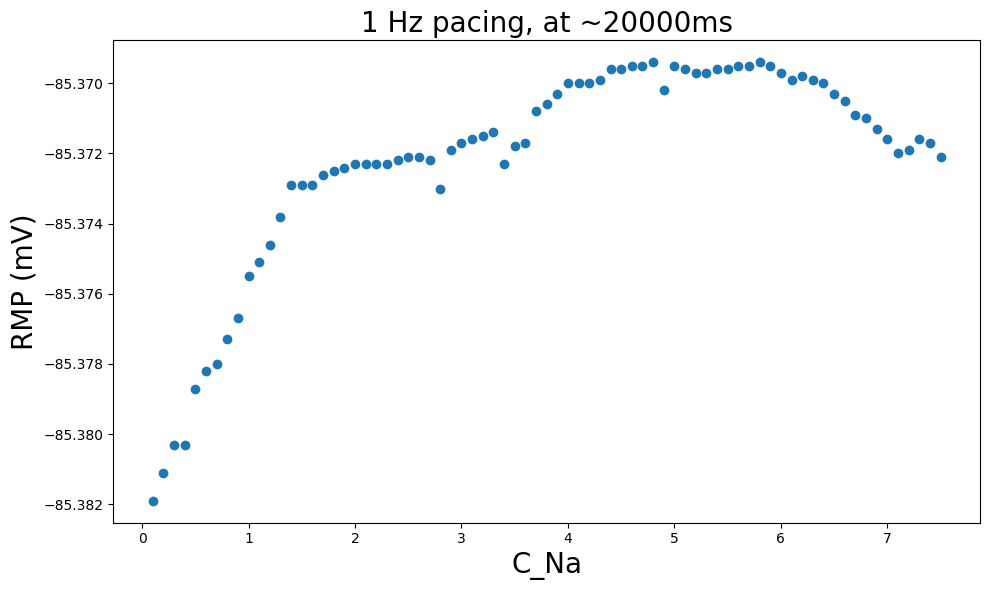

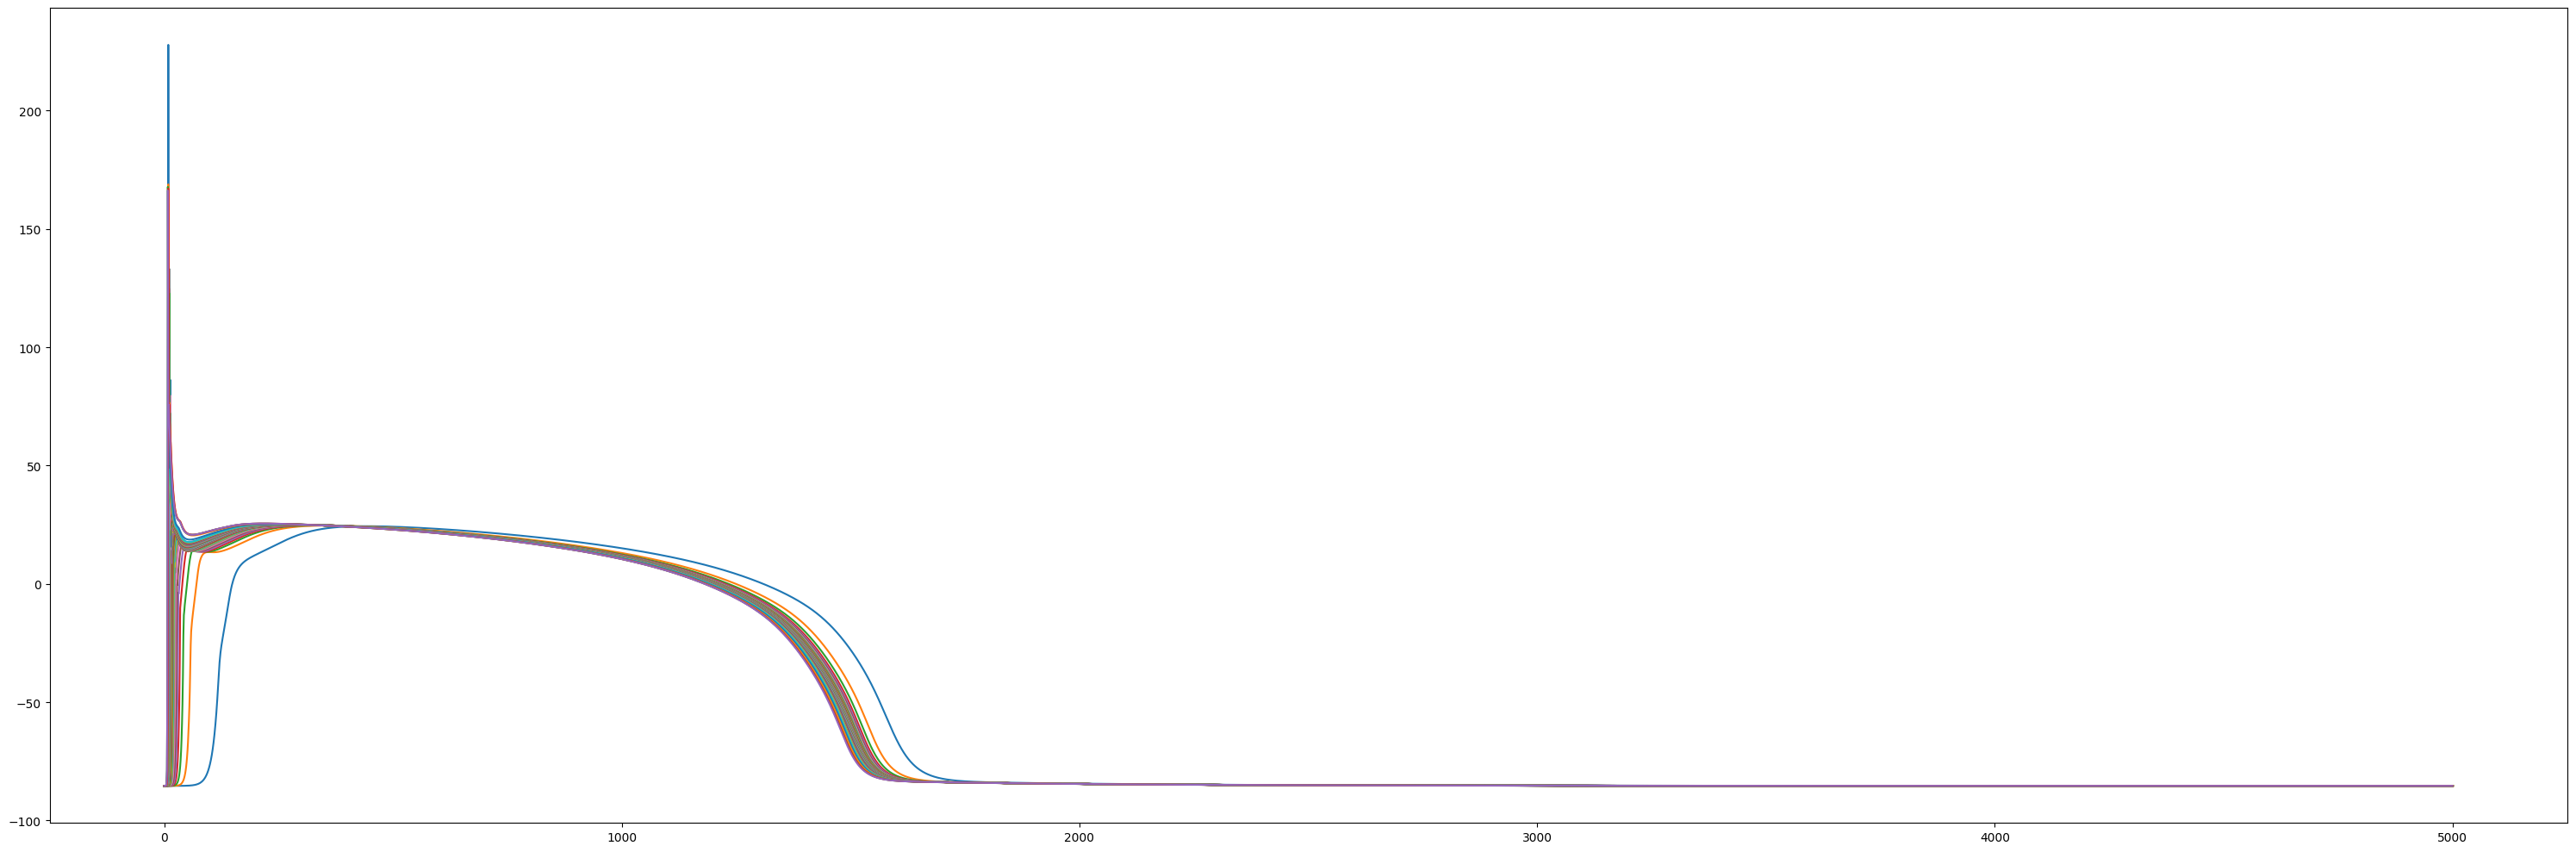

In [146]:
# plot APD_90 scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), APD_90_lst)
plt.ylabel("APD 90 (ms)",size=20)
plt.xlabel("C_Na",size=20)
plt.title("1 Hz pacing, at ~20000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_Na_APD90_vs_CNa.png", dpi=300)

# plot plateau_duration scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), plateau_duration_lst)
plt.ylabel("Plateau Duration (ms)",size=20)
plt.xlabel("C_Na",size=20)
plt.title("1 Hz pacing, at ~20000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_Na_PlateauDuration_vs_CNa.png", dpi=300)

# plot dv_dt_max scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), dv_dt_max_lst)
plt.ylabel("dv/dt max (mV/ms)",size=20)
plt.xlabel("C_Na",size=20)
plt.title("1 Hz pacing, at ~20000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_Na_dv_dt_max_vs_CNa.png", dpi=300)

# plot v_peak scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), v_peak_lst)
plt.ylabel("V Peak (mV)",size=20)
plt.xlabel("C_Na",size=20)
plt.title("1 Hz pacing, at ~20000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_Na_VPeak_vs_CNa.png", dpi=300)

# plot RMP scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), RMP_lst)
plt.ylabel("RMP (mV)",size=20)
plt.xlabel("C_Na",size=20)
plt.title("1 Hz pacing, at ~20000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_Na_RMP_vs_CNa.png", dpi=300)

# plot all APs in one plot and give gradient color for  Na value
plt.figure(figsize=(30,10))
for key_Na in sorted(voltage.keys()):
    APs, starting_indexes = get_AP(voltage[key_Na])
    last_AP = APs[-1]
    plt.plot(last_AP, label=f"Na={key_Na:.1f}")
plt.tight_layout()
plt.savefig("TNNP_Na_AllAPs.png", dpi=300)


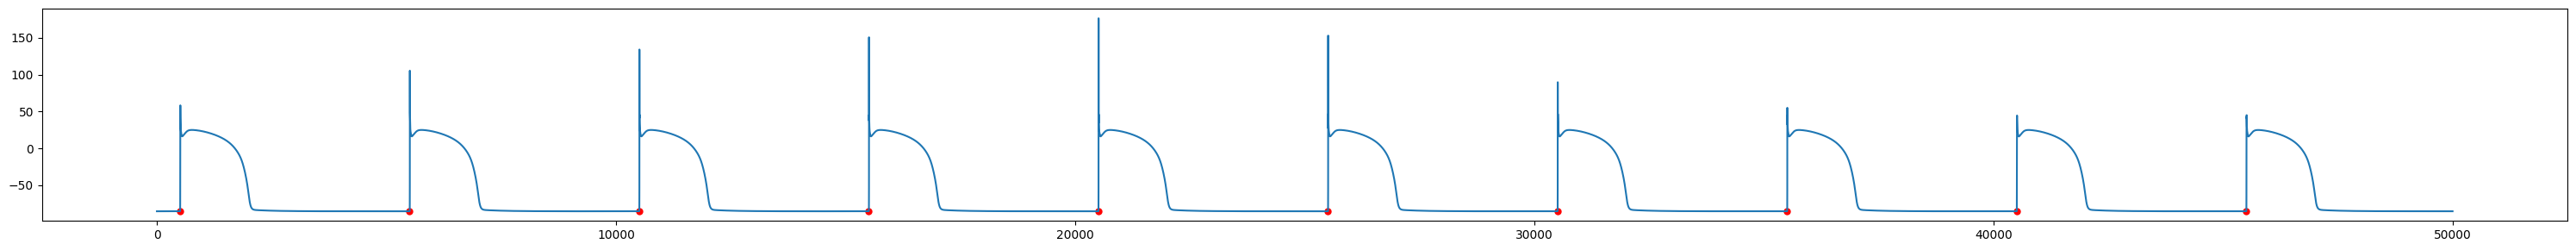

In [142]:
APs, starting_indexes = get_AP(voltage[5.9])
plt.figure(figsize=(30,3))
# now plot each starting point based on their index, plot points not lines
for start_idx in starting_indexes:
    plt.plot(start_idx, voltage[5.9][start_idx], 'ro', markersize=5) # size 10 red dot
plt.plot(voltage[5.9])
plt.tight_layout()
plt.savefig("TNNP_Na_AP_segment.png", dpi=300)

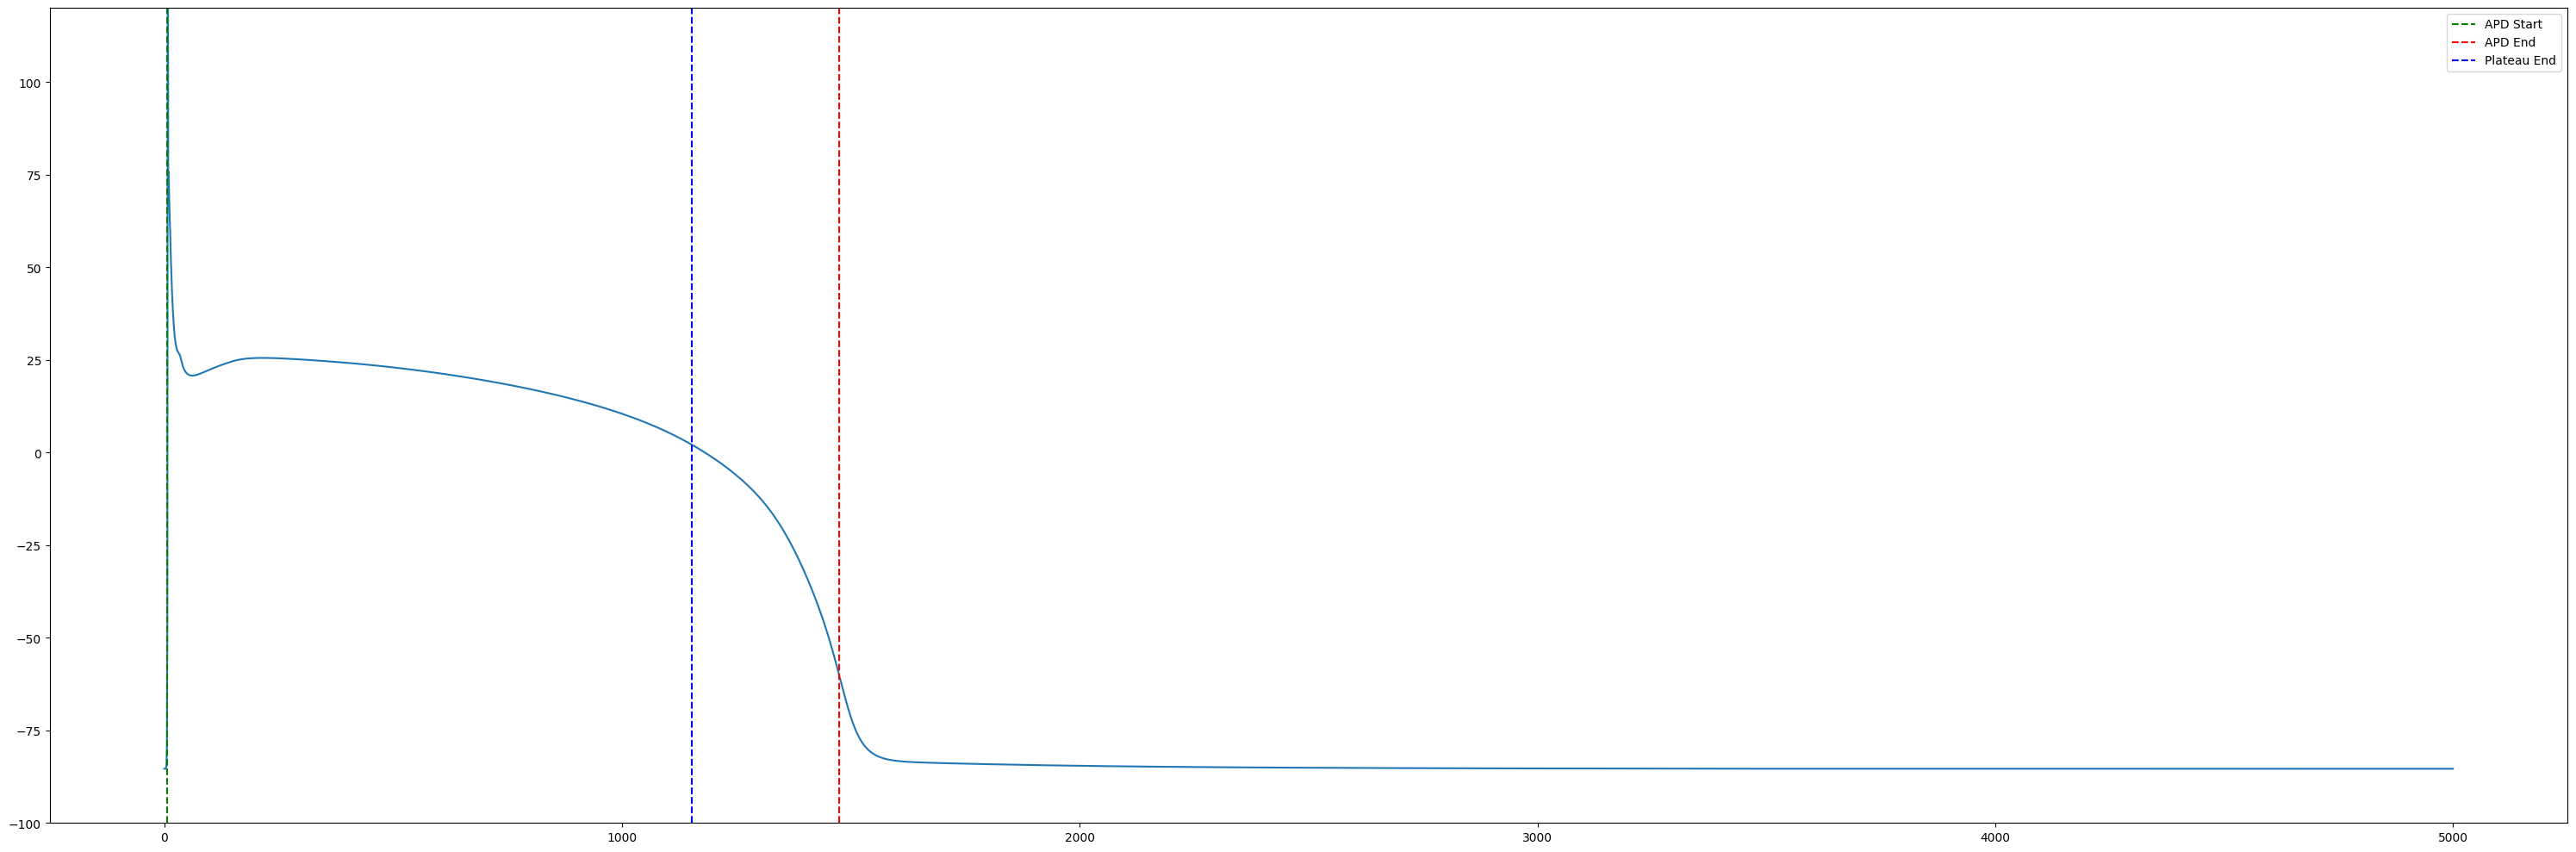

In [140]:
plt.figure(figsize=(30,10))
plt.ylim(-100,120)
last_AP = APs[-1]
plt.plot(last_AP)
dvdt_max,plateau_duration, plateau_end_idx = get_dvdt_max_and_plateau_duration(last_AP, dt=0.2) # dt=0.2 ms\
APD, APD_boundary = get_APD(last_AP, dt=0.2, APD_percentage=0.1)
# plot apd boundary, plateau_end as vertical line
plt.axvline(x=APD_boundary[0], color='g', linestyle='--', label='APD Start')
plt.axvline(x=APD_boundary[1], color='r', linestyle='--', label='APD End')
plt.axvline(x=plateau_end_idx, color='b', linestyle='--', label='Plateau End')
plt.legend()
plt.tight_layout()
plt.savefig("TNNP_Na_AP.png", dpi=300)

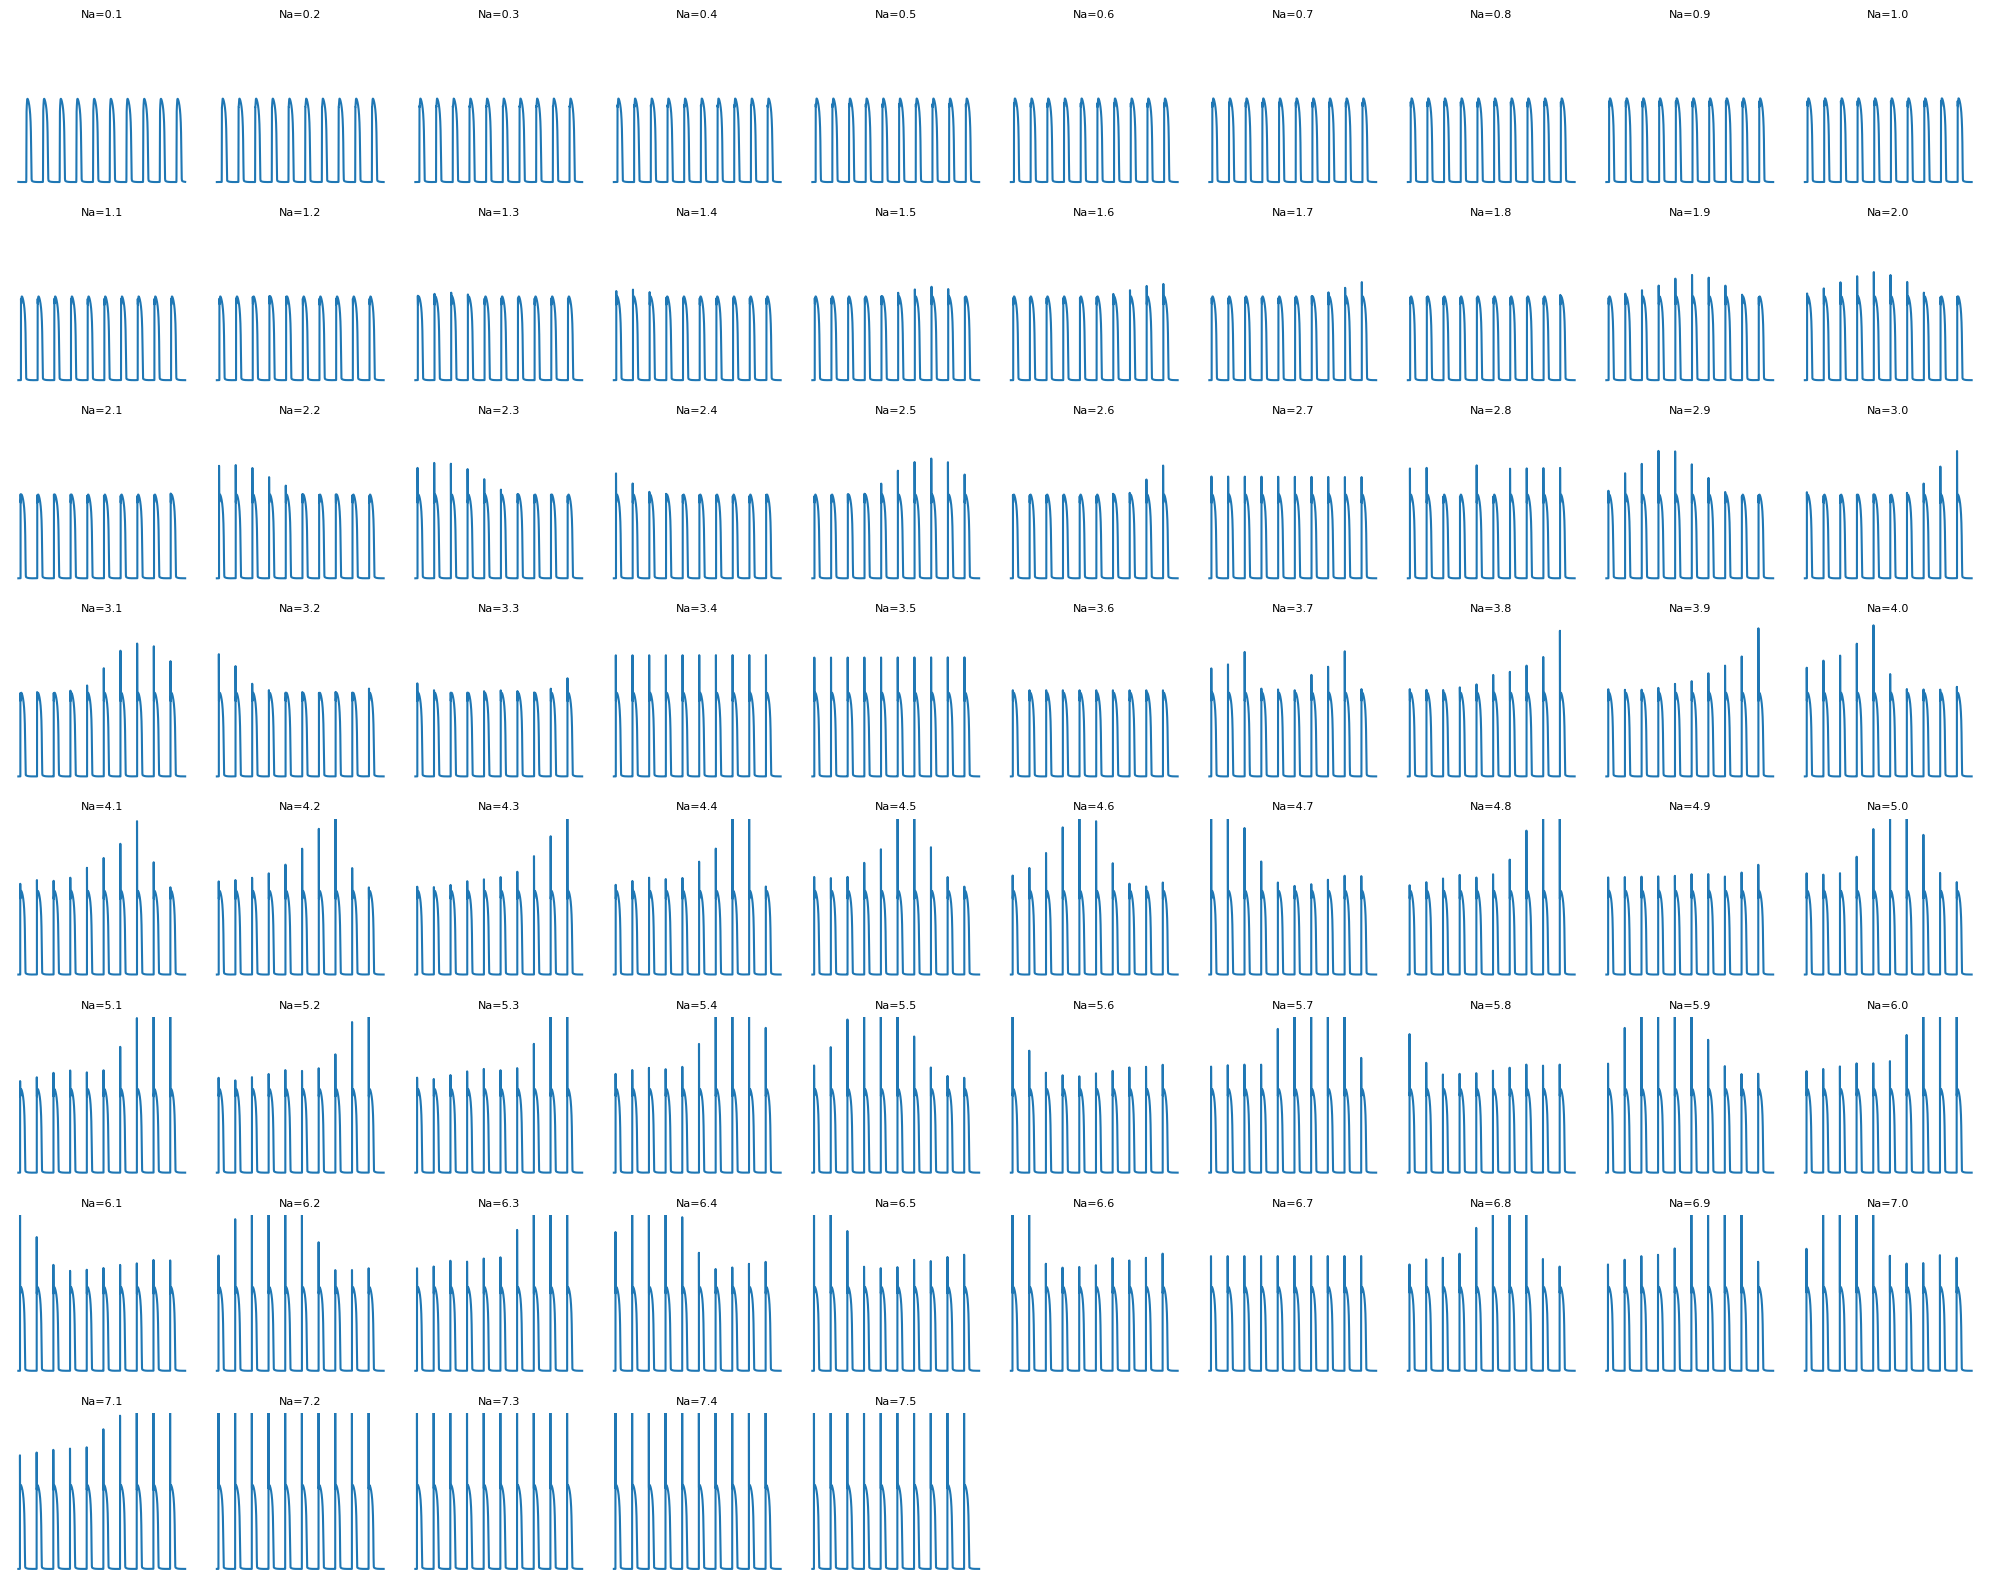

In [139]:


# 1. Create an 8x10 grid (80 slots for 75 plots)
fig, axs = plt.subplots(8, 10, figsize=(20, 16))

# Start the 'Na' key value
key_Na = 0.1

# 2. Flatten the grid to a single list for easy looping
# Enumerate over the 80 subplot axes in the flattened array
for i, ax in enumerate(axs.flat):
    
    # We only want to plot in the first 75 subplots
    if i < 75:
        # Check if the data for the current key exists
        if key_Na in voltage:
            
            # --- 🎯 THE FIX ---
            # Use ax.plot() directly on the subplot axis object to draw a line graph.
            ax.plot(voltage[key_Na], color='C0')
            ax.set_ylim(-100,120)
            # Set the title with the current Na value
            ax.set_title(f"Na={key_Na:.1f}", fontsize=8)
            
            # Optional: Customize axes for line plots
            ax.set_xticks([]) # Remove x-ticks
            ax.set_yticks([]) # Remove y-ticks
            
            # Increment the key for the next subplot
            key_Na += 0.1
            key_Na = round(key_Na, 1) # Use round to prevent floating point errors
        
        else:
            # Handle case where the expected data key is missing (optional)
            ax.text(0.5, 0.5, "Data Missing", transform=ax.transAxes, ha='center')
            
    # Always turn off the axis for all subplots for a clean look
    ax.axis('off')

# 3. Adjust layout and display
plt.tight_layout()
plt.savefig("TNNP_Na_Variation.png", dpi=300)